# Expert-taxonomy tree exploration

**Status (2026-05-20).** The original `build_hierarchy → refine_parent →
meta_merge` (R1-refined / R2 / R3) pipeline is **deprecated**. It was muddled
across granularity levels and confounded "same rubric" with "same principle".
The replacement is a clean 4-level grain documented in
[`notes/2026-05-19__structural-metrics.md`](../notes/2026-05-19__structural-metrics.md)
§7:

- **L0 cluster** — *same rubric, restated*. Locked pipeline: canonicalize →
  judge-distilled LoRA + ModernBERT-CE → kNN + blend affinity → average-linkage
  at tau 0.825. Validated against a v6 graded judge. **~33K L0 clusters
  across 11 tasks.**
- **R1 rule** — *different rubrics, same underlying principle*. Per-batch LLM
  grouping (Llama-3.3-70B). Target ~12–15K. **In progress on sk3** —
  `peer-review` is the first task built (676 families from 1,871 L0 clusters).
- **R2 criterion family** — *different principles, same aspect of evaluation*.
  Target ~1.5–3K. Pending.
- **R3 theme** — *different aspects, same broad concern*. Target ~200–300.
  Pending.

This notebook is reorganized as:

- **§1–3 (new): peer-review walk-through of the L0 + R1 pipeline.** Uses
  `outputs/analyses/structural_metrics/clusters_peer-review.json` (L0) and
  `r1_families_peer-review.json` (R1) — both mirrored locally from sk3.
- **§4 (new): per-task L0 summary.** Concentration + bucket breakdown from
  the structural-metrics artifacts.
- **§5+ (legacy): old R1-refined / R2 / R3 hierarchy stats** are kept below
  as historical orientation. They are **not the production pipeline.**

Inputs new pipeline → `outputs/analyses/structural_metrics/`.
Inputs legacy → `outputs/hierarchy/` (produced by `scripts/build_hierarchy.py`,
`scripts/refine_parent.py`, `scripts/meta_merge.py`).


In [15]:
import json
from html import escape as _h
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

ROOT = Path("/Users/spangher/Projects/stanford-research/norm-research")
ANALYSES = ROOT / "outputs" / "analyses"
SM   = ANALYSES / "structural_metrics"           # new pipeline (L0, R1)
HIER = ROOT / "outputs" / "hierarchy"            # legacy pipeline (R1-refined, R2, R3)
CANON = ANALYSES / "canon_all_real_forms.jsonl"  # 53,413 canonical leaves
CACHE = ROOT / "notebooks" / "_explore_cache"    # pages.parquet / rubrics.parquet

TASKS = [
    "code-review", "creative-writing", "grant-funding", "humor",
    "legal-outcome-prediction", "math-stackexchange", "news-homepages",
    "notice-and-comment", "patents", "peer-review", "press-releases",
]
BUCKETS = ["general", "specific", "hyper_specific"]

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

# Load canonical-form text by key (for showing example leaves in clusters)
# and load the rubric frame (raw rubric text per key) for the same purpose.
canon_by_key = {}
bucket_counts = Counter()
with open(CANON) as f:
    for line in f:
        o = json.loads(line)
        canon_by_key[o["key"]] = o["canonical"]
        bucket_counts[(o["task"], o["bucket"])] += 1

rubrics_df = pd.read_parquet(CACHE / "rubrics.parquet")
# Build a key → raw rubric lookup so we can show the original text alongside the canonical
def _key_from_row(r):
    return f"{r['task']}::{r['source_dir']}::{r['page_id'].split('::', 2)[-1]}::{r['rubric_idx']}"
# rubric provenance key: task::source_dir::source_file::rubric_idx (matches canonicalize)
rubrics_df["key"] = (
    rubrics_df["task"] + "::" + rubrics_df["source_dir"] + "::" +
    rubrics_df["page_id"].str.split("::").str[-1] + "::" +
    rubrics_df["rubric_idx"].astype(str)
)
raw_by_key = dict(zip(rubrics_df["key"], rubrics_df["rubric_name"]))

print(f"canon leaves: {len(canon_by_key):,}  ·  raw rubrics: {len(raw_by_key):,}")


canon leaves: 53,413  ·  raw rubrics: 361,050


## 1. New pipeline — peer-review L0 clusters at a glance

`clusters_peer-review.json` is the locked output of the L0 stage: a dict
mapping each canonical-leaf key to its cluster id. Inverting the dict gives
the per-cluster membership; the size distribution tells us how much the
3,257 peer-review canonical forms compressed into "same-rubric" buckets.


peer-review L0:  3,257 canonical forms  →  1,871 clusters
  1,416 singletons (75.7% of clusters)  ·  largest cluster = 31


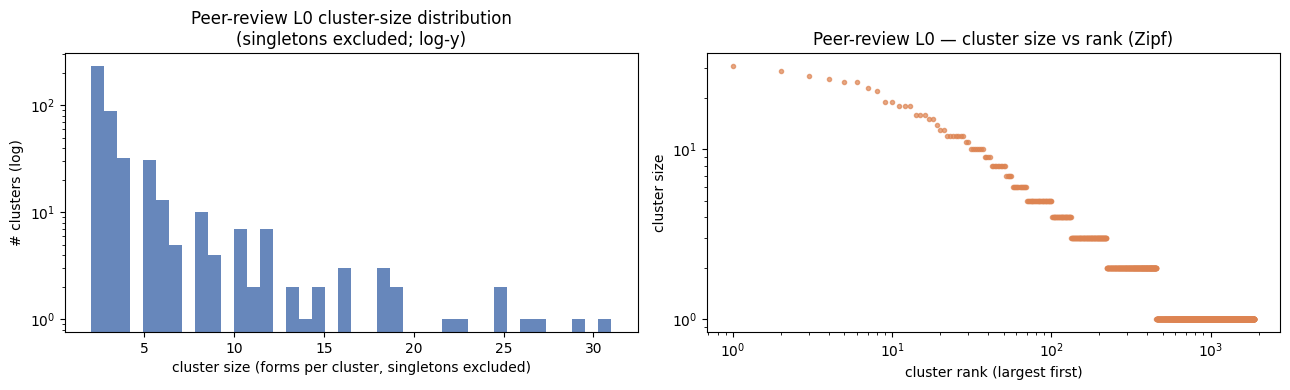

In [16]:
# Load L0 clusters (peer-review)
PR_L0 = json.loads((SM / "clusters_peer-review.json").read_text())
pr_clusters = defaultdict(list)
for k, c in PR_L0.items():
    pr_clusters[c].append(k)
pr_sizes = sorted((len(v) for v in pr_clusters.values()), reverse=True)

n_keys = len(PR_L0)
n_clu  = len(pr_clusters)
n_sing = sum(1 for s in pr_sizes if s == 1)
print(f"peer-review L0:  {n_keys:,} canonical forms  →  {n_clu:,} clusters")
print(f"  {n_sing:,} singletons ({100*n_sing/n_clu:.1f}% of clusters)  ·  "
      f"largest cluster = {pr_sizes[0]}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist([s for s in pr_sizes if s > 1], bins=40, color="#4C72B0", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_xlabel("cluster size (forms per cluster, singletons excluded)")
axes[0].set_ylabel("# clusters (log)")
axes[0].set_title("Peer-review L0 cluster-size distribution\n(singletons excluded; log-y)")

# Zipf — rank vs size (log-log)
ranks = np.arange(1, len(pr_sizes) + 1)
axes[1].loglog(ranks, pr_sizes, marker=".", linestyle="none", color="#DD8452", alpha=0.7)
axes[1].set_xlabel("cluster rank (largest first)")
axes[1].set_ylabel("cluster size")
axes[1].set_title("Peer-review L0 — cluster size vs rank (Zipf)")
plt.tight_layout()
plt.show()


## 2. Peer-review L0 — what do the largest clusters actually contain?

For each of the top L0 clusters, show a few member canonical forms with the
provenance key. These are *the same rubric, restated* — the clustering should
look like multiple paraphrases of one underlying criterion.


In [17]:
def render_cluster_card(cid, members, max_members=6, header=None, color="#4C72B0"):
    # pull a representative canonical form (the one with median length)
    canons = [canon_by_key.get(k, "(missing)") for k in members]
    rep = sorted(canons, key=lambda s: abs(len(s) - np.median([len(c) for c in canons])))[0]
    # count distinct source files (norm-strength proxy)
    src_files = {k.split("::", 3)[2] for k in members if k.count("::") >= 3}

    rows = []
    for k in members[:max_members]:
        src = k.split("::", 3)[2] if k.count("::") >= 3 else k
        canon = _h(canon_by_key.get(k, "(missing)")[:240])
        rows.append(
            f'<li style="margin:4px 0;padding:4px 8px;border-left:2px solid #cbd5e1;'
            f'background:#f8fafc;font-size:12.5px;">'
            f'<span style="color:#94a3b8;font-family:monospace;font-size:11px;">{_h(src)}</span><br>'
            f'<span style="color:#1e293b;">{canon}</span></li>'
        )
    if len(members) > max_members:
        rows.append(
            f'<li style="list-style:none;font-style:italic;color:#64748b;font-size:12px;">'
            f'… +{len(members)-max_members} more forms</li>'
        )

    header_html = (
        f'<div style="font-size:11px;color:#64748b;font-family:monospace;">{_h(header)}</div>'
        if header else ""
    )
    html = f"""
    <div style="border:1px solid #cbd5e1;border-left:5px solid {color};
                border-radius:6px;padding:10px 14px;margin:8px 0;background:#ffffff;
                font-family:-apple-system,BlinkMacSystemFont,sans-serif;
                box-shadow:0 1px 2px rgba(0,0,0,0.04);">
      {header_html}
      <div style="font-size:14.5px;font-weight:700;color:#0f172a;margin-bottom:4px;">
        L0 cluster #{cid} · {len(members)} forms · {len(src_files)} distinct sources
      </div>
      <div style="font-style:italic;color:#475569;font-size:13px;margin-bottom:6px;">
        rep: {_h(rep[:280])}
      </div>
      <ul style="list-style:none;padding-left:0;margin:0;">{''.join(rows)}</ul>
    </div>
    """
    return html


# Top 6 peer-review L0 clusters
sorted_clusters = sorted(pr_clusters.items(), key=lambda kv: -len(kv[1]))[:6]
display(HTML("<h3 style='color:#0f172a;margin:6px 0;'>Top 6 peer-review L0 clusters (largest first)</h3>"))
for cid, members in sorted_clusters:
    display(HTML(render_cluster_card(cid, members, max_members=5)))


## 3. Peer-review R1 — "same underlying principle" families over L0 clusters

`r1_families_peer-review.json` groups L0 clusters into R1 families. The LLM
proposer (Llama-3.3-70B) sees a batch of related L0 clusters with their
representative canonical forms, then proposes a family name + description
plus the subset of L0 clusters that "share one underlying principle".

Per the May-19 grain plan, a good R1 family should bundle clusters whose
pairwise judge score would mostly be **1** (related but not the same) under
**one** principle.

Below we show a few illustrative R1 families and, for each, the L0 clusters
they bundle.


R1 families: 676  (built from 1,871 L0 clusters)
  median L0/family = 2  ·  max L0/family = 20  ·  singleton families (299 = 44%)


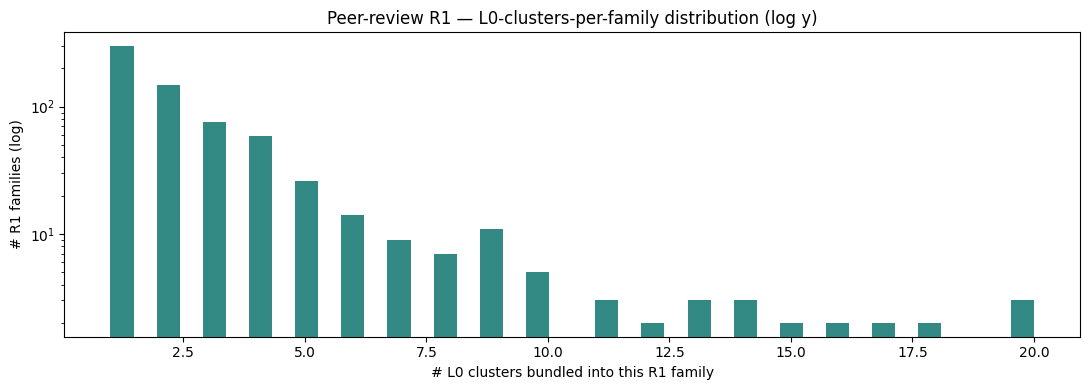


Top 12 R1 families by # L0 clusters bundled:


,name,n_L0_clusters,n_forms_rolled_up,description
family_id,,,,
14,Evidence-supported claims,20,62,"Claims, conclusions, and interpretations should be well-supported by, and not exceed, the available evidence and data."
394,Reproducibility and transparency,20,23,"The submission should provide sufficient information, data, and materials to ensure reproducibility and transparency of the work."
180,Transparent reporting,20,33,"The reporting should be complete, accurate, and transparent to enable critical appraisal, evaluation, and use of the research."
42,Ethical considerations in research,18,61,"The research should demonstrate thorough consideration and appropriate handling of ethical issues, including identification of potential ris"
11,Clear presentation,18,50,"The presentation of results, data, and information should be clear, accurate, and easy to understand."
174,Citation format and consistency,17,23,"Citations and references should be in the correct format, consistent, and properly ordered."
178,Discussing limitations,17,43,"The work should acknowledge, discuss, and disclose its limitations, including those related to methodology, data, and generalizability."
404,Proper meta-analysis handling,16,19,"The meta-analysis should properly handle or account for various factors such as pseudoreplication, non-independence, phylogenetic relationsh"
292,Study reporting transparency,16,20,"The paper should clearly report its methodology, outcomes, and results, including details on study design, data splits, and outcome measures"


In [18]:
PR_R1 = json.loads((SM / "r1_families_peer-review.json").read_text())
families = PR_R1["families"]

# Per-family: total L0 clusters + total forms-rolled-up
fam_rows = []
for f in families:
    n_l0 = len(f["cluster_ids"])
    n_forms = sum(len(pr_clusters.get(cid, [])) for cid in f["cluster_ids"])
    fam_rows.append({
        "family_id": f["family_id"],
        "name": f["name"],
        "n_L0_clusters": n_l0,
        "n_forms_rolled_up": n_forms,
        "description": f.get("description", "")[:140],
    })
fam_df = pd.DataFrame(fam_rows)

print(f"R1 families: {len(families):,}  (built from {len(pr_clusters):,} L0 clusters)")
print(f"  median L0/family = {fam_df.n_L0_clusters.median():.0f}  ·  "
      f"max L0/family = {fam_df.n_L0_clusters.max()}  ·  "
      f"singleton families ({(fam_df.n_L0_clusters == 1).sum()} = "
      f"{100 * (fam_df.n_L0_clusters == 1).sum() / len(fam_df):.0f}%)")

# Distribution of L0/family
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(fam_df.n_L0_clusters, bins=40, color="#0f766e", alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("# L0 clusters bundled into this R1 family")
ax.set_ylabel("# R1 families (log)")
ax.set_title("Peer-review R1 — L0-clusters-per-family distribution (log y)")
plt.tight_layout()
plt.show()

print("\nTop 12 R1 families by # L0 clusters bundled:")
display(
    fam_df.sort_values("n_L0_clusters", ascending=False).head(12)
          .set_index("family_id")
          .style.background_gradient(subset=["n_L0_clusters","n_forms_rolled_up"], cmap="BuGn")
)


In [19]:
# Render a few R1 families as cards — show their bundled L0 clusters and a sample canonical form per L0.
def render_r1_family_card(fam, max_clusters=5, max_forms_per_cluster=2):
    cid_list = fam["cluster_ids"]
    inner = []
    for cid in cid_list[:max_clusters]:
        members = pr_clusters.get(cid, [])
        if not members:
            continue
        canons = [canon_by_key.get(k, "") for k in members[:max_forms_per_cluster]]
        forms_html = "<br>".join(
            f'<span style="color:#334155;font-size:12.5px;">• {_h(c[:200])}</span>'
            for c in canons if c
        )
        inner.append(
            f'<div style="margin:6px 0;padding:6px 10px;background:#f8fafc;'
            f'border-left:3px solid #0f766e;border-radius:4px;">'
            f'<div style="font-size:11px;color:#64748b;font-family:monospace;">'
            f'L0 #{cid} · {len(members)} forms</div>'
            f'{forms_html}</div>'
        )
    if len(cid_list) > max_clusters:
        inner.append(
            f'<div style="color:#64748b;font-style:italic;font-size:12px;padding:4px 6px;">'
            f'… +{len(cid_list) - max_clusters} more L0 clusters bundled into this family</div>'
        )

    n_forms = sum(len(pr_clusters.get(c, [])) for c in cid_list)
    html = f"""
    <div style="border:1px solid #cbd5e1;border-left:5px solid #0f766e;
                border-radius:7px;padding:12px 16px;margin:10px 0;background:#ffffff;
                font-family:-apple-system,BlinkMacSystemFont,sans-serif;
                box-shadow:0 1px 3px rgba(0,0,0,0.05);">
      <div style="font-size:11px;color:#64748b;font-family:monospace;">
        R1 family #{fam['family_id']} · {len(cid_list)} L0 clusters · {n_forms} rolled-up forms
      </div>
      <div style="font-size:16px;font-weight:700;color:#0f172a;margin:4px 0;">
        {_h(fam['name'])}
      </div>
      <div style="color:#334155;font-size:13px;margin-bottom:6px;">
        {_h(fam.get('description', ''))}
      </div>
      {''.join(inner)}
    </div>
    """
    return html


# Pick a mix: a large family, a medium one, and a couple of more typical ones
fams_sorted = sorted(families, key=lambda f: -len(f["cluster_ids"]))
picks = [fams_sorted[0], fams_sorted[2], fams_sorted[10],
         fams_sorted[30] if len(fams_sorted) > 30 else fams_sorted[-1]]

display(HTML(
    "<h3 style='color:#0f172a;margin:6px 0;'>Peer-review R1 family examples</h3>"
    "<div style='color:#64748b;font-size:12px;'>Each card: an R1 family + its bundled "
    "L0 clusters (with 1–2 sample canonical forms per cluster).</div>"
))
for f in picks:
    display(HTML(render_r1_family_card(f, max_clusters=5, max_forms_per_cluster=2)))


## 4. Per-task L0 summary — concentration + bucket breakdown

Concentration metrics for every task's L0 clustering, plus the specificity
bucket each canonical form was assigned during canonicalization. See the
May-19 note §1–§2 for the full discussion; the short version is that
`general`-bucket forms compress 1.5–1.9× while `specific`/`hyper_specific`
stay near-singleton by design.


In [20]:
concentration = json.loads((SM / "concentration.json").read_text())
specificity   = json.loads((SM / "specificity.json").read_text())

# Combined per-task summary
rows = []
for task in TASKS:
    d = concentration.get(task, {})
    spec = specificity.get(task, {})
    rows.append({
        "task": task,
        "forms":     d.get("n_forms"),
        "L0 clusters": d.get("n_clusters"),
        "compression": d.get("compression"),
        "% singleton": round(d["pct_singleton"]*100, 1) if "pct_singleton" in d else None,
        "largest L0": d.get("largest"),
        "top10 cov %": round(d["top10"]*100, 1) if "top10" in d else None,
        "gini": d.get("gini"),
        "general forms":        spec.get("general", {}).get("forms"),
        "specific forms":       spec.get("specific", {}).get("forms"),
        "hyper_specific forms": spec.get("hyper_specific", {}).get("forms"),
    })
sum_df = pd.DataFrame(rows).set_index("task")
display(
    sum_df.style
    .format({"compression":"{:.2f}×","gini":"{:.2f}"}, na_rep="—")
    .background_gradient(subset=["forms","L0 clusters","largest L0"], cmap="Blues")
    .background_gradient(subset=["compression"], cmap="Greens")
    .background_gradient(subset=["top10 cov %","gini"], cmap="Reds")
    .set_caption("Per-task L0 summary — locked clustering (tau 0.825).")
)


,forms,L0 clusters,compression,% singleton,largest L0,top10 cov %,gini,general forms,specific forms,hyper_specific forms
task,,,,,,,,,,
code-review,12262,8118,1.51×,78.700000,73,3.500000,0.30,2519,8350.000000,1393.000000
creative-writing,4950,2941,1.68×,74.100000,42,5.400000,0.35,4950,—,—
grant-funding,2836,1657,1.71×,79.100000,44,10.200000,0.38,1389,1227.000000,220.000000
humor,5885,3407,1.73×,74.700000,114,6.500000,0.37,4158,1639.000000,88.000000
legal-outcome-prediction,3303,2268,1.46×,81.500000,97,7.500000,0.28,1578,1654.000000,71.000000
math-stackexchange,5257,3381,1.55×,76.700000,35,4.600000,0.31,2378,2184.000000,695.000000
news-homepages,3022,1610,1.88×,74.800000,96,12.500000,0.42,2497,453.000000,72.000000
notice-and-comment,2881,2046,1.41×,83.700000,23,6.200000,0.27,1350,1494.000000,37.000000
patents,4130,2397,1.72×,76.300000,110,11.600000,0.38,132,3846.000000,152.000000


---

> ## ⚠️ Legacy sections (§5–§11)
>
> Everything below comes from the **deprecated** `build_hierarchy / refine_parent /
> meta_merge` pipeline (R1-refined → R2 → R3). It is retained as historical
> orientation only — the actual production pipeline is now §1–§3 above (L0 →
> R1). See `notes/2026-05-19__structural-metrics.md` §7 for why this old grain
> was discarded ("muddled across granularity levels"). The R2 and R3 numbers
> below should be read as rough order-of-magnitude targets for the new
> pipeline's pending R2/R3 stages, not as current results.

## 5. Legacy: load all R1-refined / R2 / R3 outputs into per-cell summary frame

A "cell" = (task, bucket). Some buckets have no data (creative-writing only ran
general). R3 is skipped by `meta_merge.py` when R2 is too sparse to merge —
those rows have R3 fields NaN.


In [21]:
def _load_cell(task, bucket):
    cell = f"{task}_{bucket}"
    r1 = HIER / f"{cell}_r1_refined.json"
    if not r1.exists() and cell == "creative-writing_general":
        # cw/general used a different file name in early pipeline
        r1 = HIER / "creative-writing_general_r1_refined.json"
    r2 = HIER / f"{cell}_r2_expanded.json"
    r3 = HIER / f"{cell}_r3_expanded.json"
    stranded = HIER / f"{cell}_r1_refined_stranded.json"

    if not r1.exists():
        return None

    d1 = json.loads(r1.read_text())
    parents = d1.get("parented_trees", [])
    n_p1 = len(parents)
    n_c1 = sum(len(p.get("children", [])) for p in parents)
    n_leaves_r1 = sum(
        sum(c.get("size", len(c.get("rubrics", []))) for c in p.get("children", []))
        for p in parents
    )

    row = {
        "task": task,
        "bucket": bucket,
        "r1_parents": n_p1,
        "r1_children": n_c1,
        "r1_leaves": n_leaves_r1,
        "r1_avg_children_per_parent": n_c1 / max(1, n_p1),
    }

    if stranded.exists():
        sd = json.loads(stranded.read_text())
        row["n_stranded_children"] = sd.get("n_stranded", 0)

    if r2.exists():
        d2 = json.loads(r2.read_text())
        merged = d2.get("merged_groups", [])
        grand  = d2.get("grandparents", [])
        row.update({
            "r2_merged_groups": len(merged),
            "r2_grandparents": len(grand),
            "r2_leaves_in_merged": sum(m.get("total_leaf_rubrics", 0) for m in merged),
            "r2_leaves_in_grandparents": sum(g.get("total_leaf_rubrics", 0) for g in grand),
            "r2_merge_rate": len(merged) / max(1, n_p1),
            "r2_gp_rate": len(grand) / max(1, n_p1),
        })

    if r3.exists():
        d3 = json.loads(r3.read_text())
        row.update({
            "r3_merged_groups": len(d3.get("merged_groups", [])),
            "r3_grandparents": len(d3.get("grandparents", [])),
        })

    return row


cells = []
for task in TASKS:
    for bucket in BUCKETS:
        row = _load_cell(task, bucket)
        if row is not None:
            cells.append(row)

cells_df = pd.DataFrame(cells)
print(f"loaded {len(cells_df)} cells")
print()
print(cells_df[["task", "bucket", "r1_parents", "r1_leaves", "r2_merged_groups", "r2_grandparents", "r3_merged_groups", "r3_grandparents"]].to_string(index=False))

loaded 31 cells

                    task         bucket  r1_parents  r1_leaves  r2_merged_groups  r2_grandparents  r3_merged_groups  r3_grandparents
             code-review        general         589       3055               133               84              32.0             23.0
             code-review       specific        2678      10261               224              440              27.0             36.0
             code-review hyper_specific         246       1771                39               51               0.0             13.0
        creative-writing        general        1478       6428               371              214              70.0             42.0
           grant-funding        general         228       1628                91               49              16.0             17.0
           grant-funding       specific         224       1661                63               37               3.0             14.0
           grant-funding hyper_specific          44 

## 6. Legacy: compression rates by specificity bucket

Hypothesis (confirmed): more specific buckets see less duplicate-collapsing
(lower merge_rate). Grandparent rate stays similar or rises — even when items
don't merge as duplicates, they still cluster under shared parents.


In [22]:
print("Average compression metrics by bucket:")
agg = cells_df.groupby("bucket").agg(
    n_cells=("task", "size"),
    avg_merge_rate=("r2_merge_rate", "mean"),
    avg_gp_rate=("r2_gp_rate", "mean"),
).round(3)
agg = agg.loc[BUCKETS]
print(agg)

Average compression metrics by bucket:
                n_cells  avg_merge_rate  avg_gp_rate
bucket                                              
general              11           0.283        0.190
specific             10           0.189        0.164
hyper_specific       10           0.120        0.287


In [23]:
pivot_merge = cells_df.pivot(index="task", columns="bucket", values="r2_merge_rate")[BUCKETS]
pivot_merge_pct = (pivot_merge * 100).round(0).astype("Int64")
print("\nMerge rate (%) per task × bucket:")
pivot_merge_pct


Merge rate (%) per task × bucket:


bucket,general,specific,hyper_specific
task,,,
code-review,23,8,16
creative-writing,25,<NA>,<NA>
grant-funding,40,28,7
humor,25,15,5
legal-outcome-prediction,33,13,0
math-stackexchange,28,12,15
news-homepages,24,25,14
notice-and-comment,22,11,2
patents,25,23,35


## 7. Legacy: distribution of merged_group sizes — per task (general bucket)


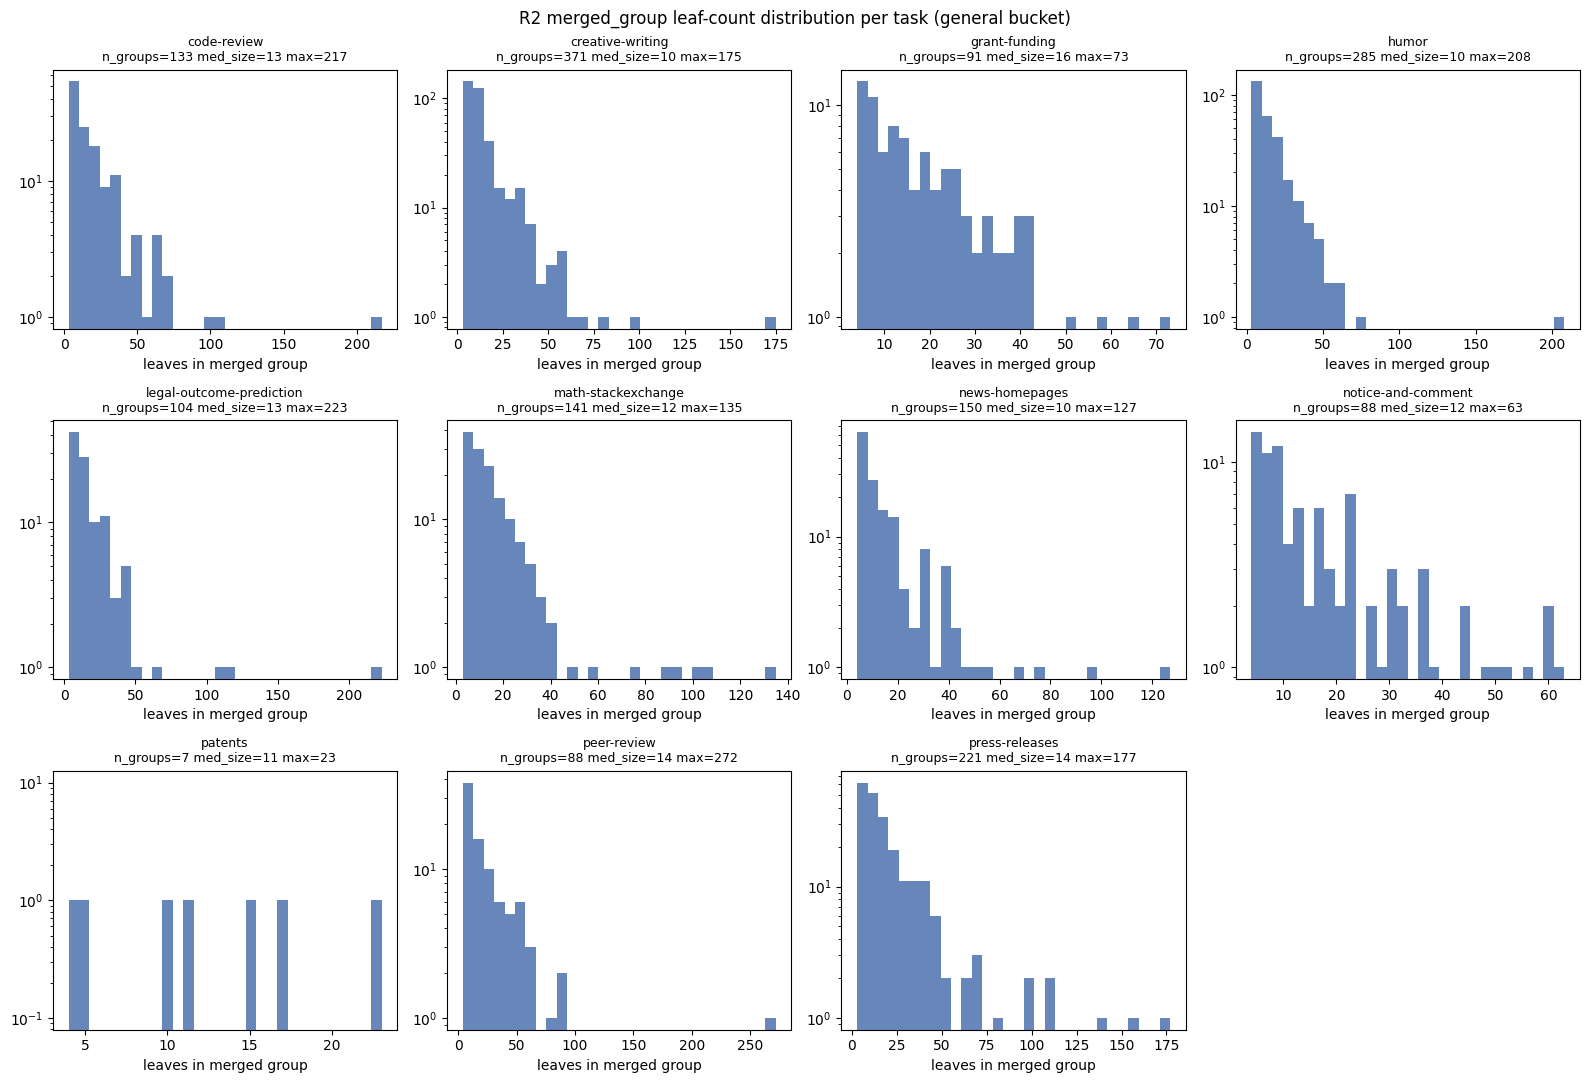

In [24]:
def _r2_merged_groups(task, bucket):
    p = HIER / f"{task}_{bucket}_r2_expanded.json"
    if not p.exists():
        return []
    return json.loads(p.read_text()).get("merged_groups", [])


def _r2_grandparents(task, bucket):
    p = HIER / f"{task}_{bucket}_r2_expanded.json"
    if not p.exists():
        return []
    return json.loads(p.read_text()).get("grandparents", [])


fig, axes = plt.subplots(3, 4, figsize=(16, 11), sharex=False)
for ax, task in zip(axes.flat, TASKS):
    mg = _r2_merged_groups(task, "general")
    sizes = [m.get("total_leaf_rubrics", 0) for m in mg]
    if not sizes:
        ax.set_title(task)
        ax.set_visible(False)
        continue
    ax.hist(sizes, bins=30, color="#4C72B0", alpha=0.85)
    ax.set_title(f"{task}\nn_groups={len(mg)} med_size={int(np.median(sizes))} max={max(sizes)}", fontsize=9)
    ax.set_xlabel("leaves in merged group")
    ax.set_yscale("log")
for ax in axes.flat[len(TASKS):]:
    ax.set_visible(False)
fig.suptitle("R2 merged_group leaf-count distribution per task (general bucket)")
plt.tight_layout()
plt.show()

## 8. Legacy: top concepts per task (R2 merged_groups, general bucket)

A first qualitative pass — what evaluation categories emerged at scale under
the old pipeline. Useful to compare against the new R1 families in §3.


In [25]:
TOP_N = 15
for task in TASKS:
    mg = sorted(_r2_merged_groups(task, "general"), key=lambda m: -m.get("total_leaf_rubrics", 0))
    if not mg:
        continue
    print(f"\n=== {task}  (top {min(TOP_N, len(mg))} of {len(mg)} merged groups) ===")
    for m in mg[:TOP_N]:
        n = m.get("total_leaf_rubrics", 0)
        nm = (m.get("merged_name") or "")[:80]
        print(f"  [{n:>3}]  {nm}")


=== code-review  (top 15 of 133 merged groups) ===
  [217]  Simplicity (KISS/YAGNI) and complexity management
  [105]  Intention‑revealing naming and conventions
  [100]  Appropriate use of established design patterns
  [ 71]  Change description clarity, completeness, and rationale (commits, PRs, changelog
  [ 68]  Testing strategy and layering (pyramid)
  [ 67]  Accessibility and inclusive design practices
  [ 64]  Code smells: identification and targeted refactoring
  [ 63]  Conventions adherence (local and ecosystem)
  [ 61]  Code style guide adherence and consistency
  [ 56]  Small, cohesive functions and decomposition
  [ 51]  Control-flow clarity and low cognitive complexity
  [ 50]  Documentation quality, structure, and audience fit
  [ 50]  Naming clarity, consistency, and conventions
  [ 48]  Performance optimization discipline
  [ 44]  Design patterns literacy and contextual application

=== creative-writing  (top 15 of 371 merged groups) ===
  [175]  Show–Tell Balance and D

## 9. Legacy: R3 grandparents per task — higher-level categories


In [26]:
def _r3_grandparents(task, bucket):
    p = HIER / f"{task}_{bucket}_r3_expanded.json"
    if not p.exists():
        return []
    return json.loads(p.read_text()).get("grandparents", [])


for task in TASKS:
    gp = sorted(_r3_grandparents(task, "general"), key=lambda g: -g.get("n_children", 0))
    if not gp:
        continue
    print(f"\n=== {task}  R3 grandparents (top {min(TOP_N, len(gp))} of {len(gp)}) ===")
    for g in gp[:TOP_N]:
        nc = g.get("n_children", 0)
        nl = g.get("total_leaf_rubrics", 0)
        nm = (g.get("grandparent_name") or "")[:80]
        print(f"  [{nc:>3} children, {nl:>4} leaves]  {nm}")


=== code-review  R3 grandparents (top 15 of 23) ===
  [  8 children,   67 leaves]  Modularity, cohesion, and coupling control
  [  7 children,  239 leaves]  Change submission quality and reviewability
  [  5 children,   64 leaves]  Formatting standards and tooling
  [  5 children,   77 leaves]  Error handling quality and robustness
  [  4 children,  127 leaves]  Refactoring discipline and smell remediation
  [  4 children,  149 leaves]  Testing strategy and layering
  [  4 children,   26 leaves]  Behavior‑centric testing and specification
  [  4 children,   89 leaves]  Public API usability and documentation
  [  4 children,  242 leaves]  Simplicity, explicitness, and avoidance of over‑engineering
  [  4 children,   81 leaves]  Performance engineering discipline
  [  4 children,   60 leaves]  Distributed resilience and reliability engineering
  [  4 children,   68 leaves]  Observability and diagnostics
  [  4 children,  104 leaves]  Accessibility and inclusive design
  [  4 children,  

## 10. Legacy: coverage / stranded children — what got dropped during refinement?

Refinement removes children that don't fit their assigned parent (misfits).
A high stranded fraction in a task hints that R1 parents were noisy and many
children were forcibly grouped — a key motivating signal for moving to the
judge-grounded L0/R1 grain.


In [27]:
strand_rows = []
for task in TASKS:
    for bucket in BUCKETS:
        p = HIER / f"{task}_{bucket}_r1_refined_stranded.json"
        if not p.exists():
            continue
        sd = json.loads(p.read_text())
        n_stranded = sd.get("n_stranded", 0)
        # find corresponding refined-input children count
        cell_row = cells_df[(cells_df.task == task) & (cells_df.bucket == bucket)]
        if cell_row.empty:
            continue
        n_children = int(cell_row.iloc[0]["r1_children"])
        strand_rows.append({
            "task": task,
            "bucket": bucket,
            "n_stranded": n_stranded,
            "n_kept_children": n_children,
            "stranded_pct": 100 * n_stranded / max(1, n_stranded + n_children),
        })
strand_df = pd.DataFrame(strand_rows)
print("Stranded children per cell (children dropped from parents as misfits):\n")
print(strand_df.sort_values(["task", "bucket"]).to_string(index=False))

Stranded children per cell (children dropped from parents as misfits):

                    task         bucket  n_stranded  n_kept_children  stranded_pct
             code-review        general         179             2255      7.354150
             code-review hyper_specific          66              859      7.135135
             code-review       specific         313             7909      3.806860
        creative-writing        general         495             5180      8.722467
           grant-funding        general         112             1094      9.286899
           grant-funding hyper_specific          15              199      7.009346
           grant-funding       specific          68             1041      6.131650
                   humor        general         480             4307     10.027157
                   humor hyper_specific           6              136      4.225352
                   humor       specific         158             1912      7.632850
legal-outcome-p

## 11. Legacy: compression ratio R1-leaves → R2-merged_groups, visual


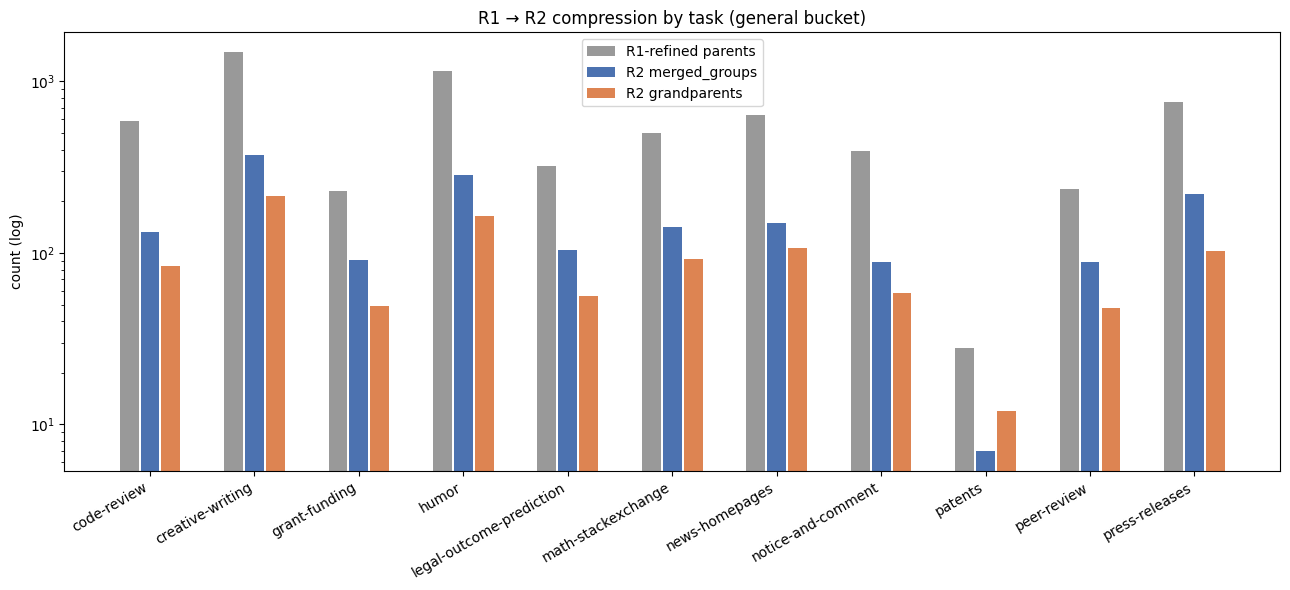

In [28]:
fig, ax = plt.subplots(figsize=(13, 6))
g_cells = cells_df[cells_df.bucket == "general"].sort_values("task")
x = np.arange(len(g_cells))
ax.bar(x - 0.2, g_cells["r1_parents"], width=0.18, label="R1-refined parents", color="#999999")
ax.bar(x,        g_cells["r2_merged_groups"], width=0.18, label="R2 merged_groups", color="#4C72B0")
ax.bar(x + 0.2,  g_cells["r2_grandparents"], width=0.18, label="R2 grandparents", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(g_cells["task"], rotation=30, ha="right")
ax.set_yscale("log")
ax.set_ylabel("count (log)")
ax.set_title("R1 → R2 compression by task (general bucket)")
ax.legend()
plt.tight_layout()
plt.show()

---

## 12. Status of the original Phase 2–4 stubs (now resolved elsewhere)

The stubs that were originally below this section have all been addressed by
the new pipeline; they are no longer phase-2/3/4 of the legacy hierarchy
work. Pointers:

- **Phase 2 — diffuseness per merged_group.** Replaced by the locked L0
  clustering's validation pipeline: the judge-distilled CE has ρ ≈ 0.83 with
  the v6 graded judge on held-out pairs, and per-cluster spread is now
  reported as `pct_singleton` / `largest` / `gini` in `concentration.json`
  (see §4 above and §1 of the May-19 note).

- **Phase 3 — source-origin distribution per merged_group.** Done as the
  **consensus** analysis (May-19 note §6): for each L0 cluster we count
  distinct source files in its provenance keys. 98% of multi-member L0
  clusters draw from ≥2 distinct sources — the clustering is overwhelmingly
  cross-source. Per-task summary + top concepts live in
  `outputs/analyses/structural_metrics/consensus.json` and
  `consensus_top_concepts.json` (rendered in NB1 §16).

- **Phase 4 — cross-task concept overlap.** Done as the **universal
  concepts** analysis (May-19 note §4): 58 concepts span ≥3 tasks at
  cos ≥ 0.86, with a clean task-family structure (May-19 §5). See
  `universal_concepts_v2.json` and `task_pair_sharing.json` (rendered in
  NB1 §15 and §17).

The next deliverables for **this** notebook are the new R2 / R3 / R4 levels
once the per-batch LLM grouping has been run for all 11 tasks on sk3.
